In [1]:
import pandas as pd
import numpy as np
import muspan as ms
import os
import seaborn as sns
from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42     
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['font.sans-serif'] = 'Arial'

In [27]:
def plotDistanceCor(domain,max_r,annulus_width):
    q_1 = ms.query.query(domain, ('label', 'tacco'), 'is', 'LASP2')
    q_2 = ms.query.query(domain, ('label', 'tacco'), 'is', 'T_cells')
    q_3 = ms.query.query(domain, ('label', 'tacco'), 'is', 'LASP5')
    q_4 = ms.query.query(domain, ('label', 'tacco'), 'is', 'LASP_Other')
    radii_inner_1_2, cross_PCF_1_2 = ms.spatial_statistics.cross_pair_correlation_function(
        domain,
        population_A=q_1,
        population_B=q_2,
        include_boundaries=None,
        max_R=max_r,
        #annulus_step=10,
        annulus_width=annulus_width,
        exclude_zero=True,
        boundary_exclude_distance=20)

    radii_inner_2_2, cross_PCF_2_2 = ms.spatial_statistics.cross_pair_correlation_function(
        domain,
        population_A=q_3,
        population_B=q_2,
        include_boundaries=None,
        max_R=max_r,
        #annulus_step=10,
        annulus_width=annulus_width,
        exclude_zero=True,
        boundary_exclude_distance=20)

    radii_inner_4_2, cross_PCF_4_2 = ms.spatial_statistics.cross_pair_correlation_function(
        domain,
        population_A=q_4,
        population_B=q_2,
        include_boundaries=None,
        max_R=max_r,
        #annulus_step=10,
        annulus_width=annulus_width,
        exclude_zero=True,
        boundary_exclude_distance=20)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    # Add a horizontal line at y=1 for reference
    ax.axhline(1, linestyle='--', color='black')
    # Plot the Pair Correlation Function (PCF)
    sns.lineplot(x=radii_inner_2_2, y=cross_PCF_2_2, ax=ax, linewidth=4.5, label='LASP5 : T_cells', color='#9467bd')
    sns.lineplot(x=radii_inner_1_2, y=cross_PCF_1_2, ax=ax, linewidth=4.5, label='LASP2 : T_cells', color='#d62728')
    sns.lineplot(x=radii_inner_4_2, y=cross_PCF_4_2, ax=ax, linewidth=4.5, label='LASP_Other : T_cells', color='#e377c2')
    # Axis tidying
    ax.set_xlabel('Radius, r (µm)')
    ax.set_ylabel('Pair Correlation Function, g(r)')
    ax.legend(loc='upper left', bbox_to_anchor=(0.47, 0.85))
    return fig

### AL1425

In [4]:
aa = pd.read_csv(folder+'results/AL1425/data4muspan_um.csv',index_col=0)
y_min, y_max = aa['Y'].min(), aa['Y'].max()
aa['Y'] = y_max + y_min - aa['Y']
aa.head()

,in_tissue,array_row,array_col,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,n_counts,Muscle,tacco_adipocyte,tacco_adipocyte_mix,lasp_ct,tacco_adipocyte_mix_muscle,X,Y
s_008um_00260_00253-1,1,260,253,342,5.837730,413.0,6.025866,29.297821,41.404358,65.617433,100.0,413.0,No,LASP_Other,LASP_Other,LASP_Other,LASP_Other,11419.615279,7309.344015
s_008um_00266_00304-1,1,266,304,286,5.659482,330.0,5.802118,28.484848,43.636364,73.939394,100.0,330.0,No,LASP_Other,Mixed,Background,Mixed,11011.233352,7263.855044
s_008um_00278_00363-1,1,278,363,64,4.174387,67.0,4.219508,79.104478,100.000000,100.000000,100.0,67.0,No,Adipocyte,Adipocyte,Background,Adipocyte,10538.543451,7170.749098
s_008um_00474_00567-1,1,474,567,313,5.749393,379.0,5.940171,28.759894,43.799472,70.184697,100.0,379.0,No,BMYO,Mixed,Background,Mixed,8896.535269,5612.435335
s_008um_00395_00261-1,1,395,261,446,6.102559,529.0,6.272877,23.818526,34.593573,53.497164,100.0,529.0,No,Fibroblast,Fibroblast,Background,Fibroblast,11348.919101,6229.440455


In [10]:
aa = aa.dropna()

(<Figure size 640x480 with 2 Axes>, <Axes: >)

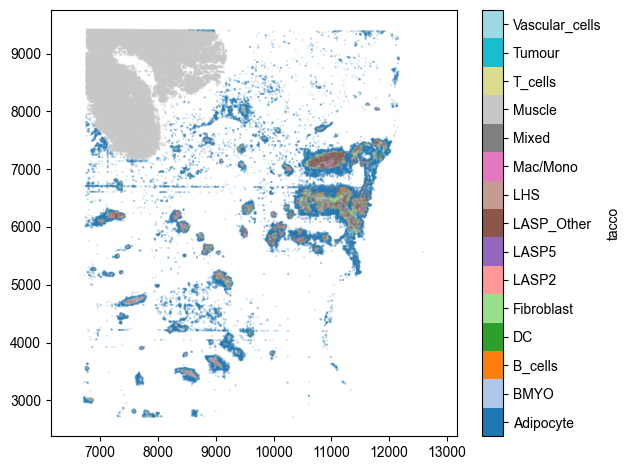

In [15]:
points = np.asarray([aa['X'], aa['Y']])
domain = ms.domain('AA')
domain.add_points(points.T, 'Cell centres')
domain.add_labels('tacco', aa['tacco_adipocyte_mix_muscle'])
ms.visualise.visualise(domain, 'tacco', ax=plt.gca(),marker_size=0.01)

In [16]:
domain.estimate_boundary(method='alpha shape',
                                 alpha_shape_kwargs={'alpha':100},remove_objects_outside_boundary=True)

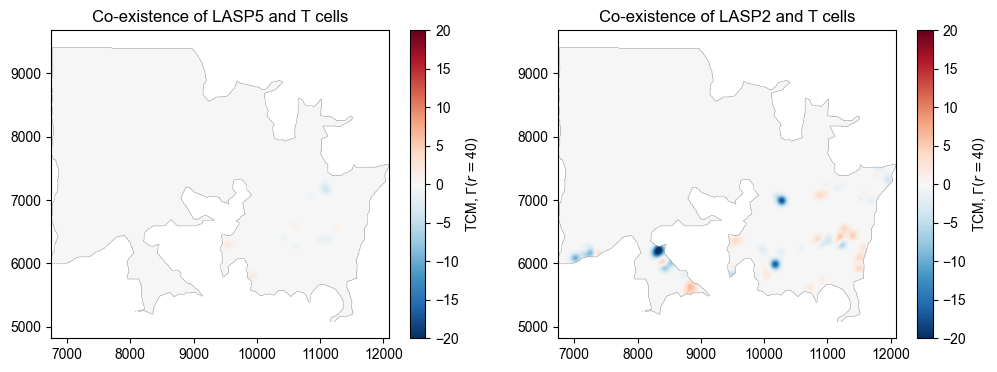

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ms.spatial_statistics.topographical_correlation_map(domain, 
                                                    ('tacco', 'LASP5'),
                                                    ('tacco', 'T_cells'), 
                                                    radius_of_interest=40,
                                                    visualise_output=True,
                                                    #kernel_radius=30,
                                                    #include_boundaries=('Collection', 'PanCK'),
                                                    visualise_tcm_kwargs={'ax': axes[0],'colorbar_limit':20})
axes[0].set_title('Co-existence of LASP5 and T cells')

ms.spatial_statistics.topographical_correlation_map(domain, 
                                                    ('tacco', 'LASP2'),
                                                    ('tacco', 'T_cells'), 
                                                    radius_of_interest=40,
                                                    #kernel_radius=30,
                                                    visualise_output=True, 
                                                    #include_boundaries=('Collection', 'PanCK'),
                                                    visualise_tcm_kwargs={'ax': axes[1],'colorbar_limit':20})
axes[1].set_title('Co-existence of LASP2 and T cells')
fig.savefig(folder+'/figures/AL1425/coLoc_spatial_lasp25_Tcell_boundry_limit20.pdf')

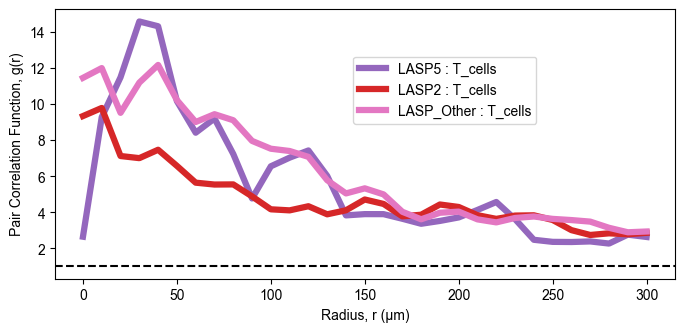

In [127]:
fig = plotDistanceCor(domain,300,20)
fig.savefig(folder+'/figures/AL1425/Distribution_LASP_T cells_colocolization.pdf')

### AA332FZ

In [59]:
aa = pd.read_csv(folder+'results/AA332FZ/data4muspan_um_new2.csv',index_col=0)
y_min, y_max = aa['Y'].min(), aa['Y'].max()
aa['Y'] = y_max + y_min - aa['Y']
#microns_per_pixel = 0.2738003670274919
#coords = aa[['X','Y']].values
#coords_um = coords * microns_per_pixel
#aa[['X','Y']] = coords_um
aa.head()

,in_tissue,array_row,array_col,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,n_counts,tacco_ct,tacco_ct_mix,tacco_lasp23,tacco_new_lasp25,tacco_adipocyte,X,Y
s_008um_00172_00448-1,1,172,448,117,4.770685,247.0,5.513429,72.874494,93.117409,100.000000,100.000000,247.0,Fibroblast,Mixed,Fibroblast,Fibroblast,Fibroblast,5496.118022,9235.917394
s_008um_00660_00606-1,1,660,606,162,5.093750,174.0,5.164786,35.632184,64.367816,100.000000,100.000000,174.0,Adipocyte,Adipocyte,Adipocyte,Adipocyte,Adipocyte,4283.011131,5316.068547
s_008um_00154_00449-1,1,154,449,932,6.838405,1163.0,7.059617,15.477214,24.075666,37.059329,62.854686,1163.0,Fibroblast,Fibroblast,Fibroblast,Fibroblast,Fibroblast,5486.248173,9379.791029
s_008um_00734_00362-1,1,734,362,84,4.442651,97.0,4.584968,64.948454,100.000000,100.000000,100.000000,97.0,Adipocyte,Adipocyte,Adipocyte,Adipocyte,Adipocyte,6242.440477,4749.531379
s_008um_00171_00505-1,1,171,505,92,4.532599,136.0,4.919981,69.117647,100.000000,100.000000,100.000000,136.0,Adipocyte,Adipocyte,Adipocyte,Adipocyte,Adipocyte,5040.078406,9237.992460


In [41]:
#tacco_ct = aa['max_ct_level_major_mc3']
#tacco_ct[tacco_ct.isin(['LASP1','LASP3','LASP4','LASP6','LASP7'])] = 'LASP_other'

In [61]:
points = np.asarray([aa['X'], aa['Y']])
domain = ms.domain('AA')
domain.add_points(points.T, 'Cell centres')
domain.add_labels('tacco', aa['tacco_adipocyte'])
#domain.add_labels('tacco_mix', aa['tacco_ct_mix'])

(<Figure size 640x480 with 2 Axes>, <Axes: >)

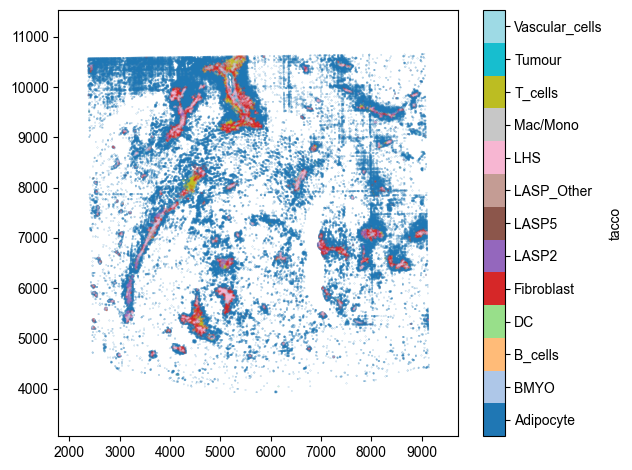

In [63]:
ms.visualise.visualise(domain, 'tacco', ax=plt.gca(),marker_size=0.01)

In [65]:
domain.estimate_boundary(method='alpha shape',
                                 alpha_shape_kwargs={'alpha':100},remove_objects_outside_boundary=True)

Text(0.5, 1.0, 'Co-existence of LASP2 and T cells')

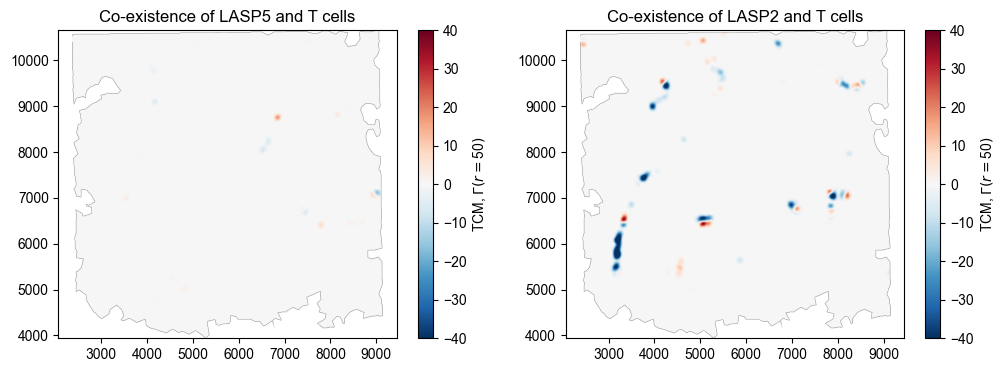

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ms.spatial_statistics.topographical_correlation_map(domain, 
                                                    ('tacco', 'LASP5'),
                                                    ('tacco', 'T_cells'), 
                                                    radius_of_interest=50,
                                                    visualise_output=True,
                                                    kernel_radius=80,
                                                    #include_boundaries=('Collection', 'PanCK'),
                                                    visualise_tcm_kwargs={'ax': axes[0],'colorbar_limit':40})
axes[0].set_title('Co-existence of LASP5 and T cells')

ms.spatial_statistics.topographical_correlation_map(domain, 
                                                    ('tacco', 'LASP2'),
                                                    ('tacco', 'T_cells'), 
                                                    radius_of_interest=50,
                                                    kernel_radius=80,
                                                    visualise_output=True, 
                                                    #include_boundaries=('Collection', 'PanCK'),
                                                    visualise_tcm_kwargs={'ax': axes[1],'colorbar_limit':40})
axes[1].set_title('Co-existence of LASP2 and T cells')
#fig.savefig(folder+'/figures/AA332FZ/coLoc_spatial_lasp25_Tcell_boundry_limit40.pdf')

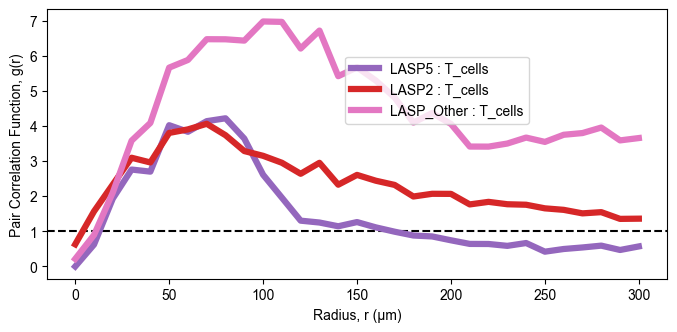

In [69]:
fig = plotDistanceCor(domain,300)
#fig.savefig(folder+'/figures/AA332FZ/Distribution_LASP_T cells_colocolization.pdf')

### AD264H1

(<Figure size 640x480 with 2 Axes>, <Axes: >)

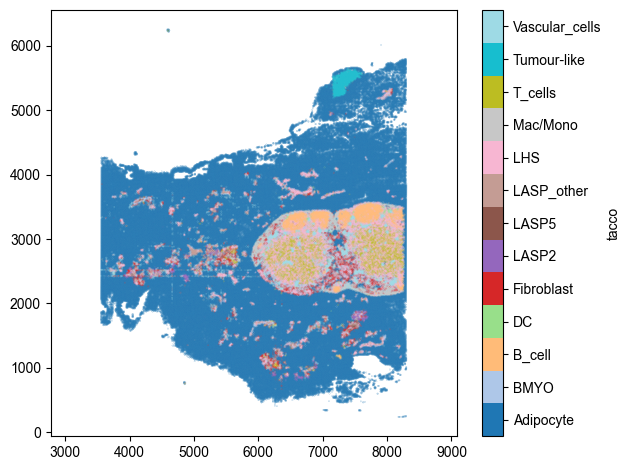

In [9]:
aa = pd.read_csv(folder+'results/AD264H1/data4muspan_adipocyte_um.csv',index_col=0)
y_min, y_max = aa['Y'].min(), aa['Y'].max()
aa['Y'] = y_max + y_min - aa['Y']
aa = aa[aa['Y']>230]
aa = aa[aa['X']<8300]

points = np.asarray([aa['X'], aa['Y']])
domain = ms.domain('BF')
domain.add_points(points.T, 'Cell centres')
domain.add_labels('tacco', aa['tacco_adipocyte'])
ms.visualise.visualise(domain, 'tacco', ax=plt.gca(),marker_size=0.01)

In [21]:
domain.estimate_boundary(method='alpha shape',
                                 alpha_shape_kwargs={'alpha':150},remove_objects_outside_boundary=True)

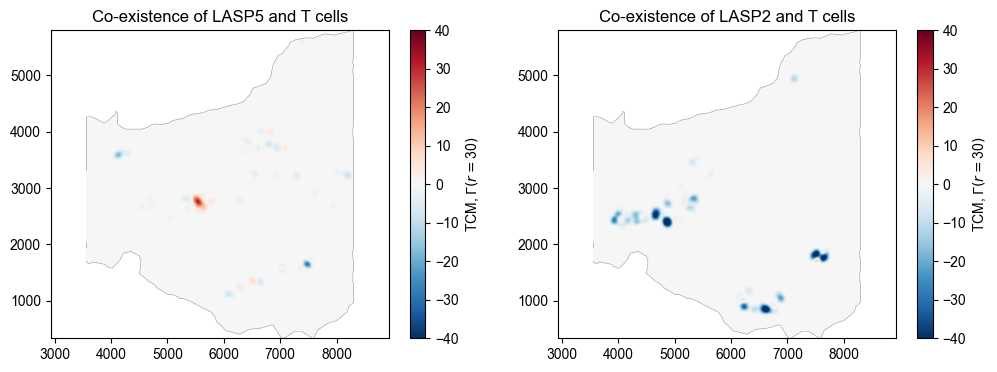

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ms.spatial_statistics.topographical_correlation_map(domain, 
                                                    ('tacco', 'LASP5'),
                                                    ('tacco', 'T_cells'), 
                                                    #max_correlation_threshold=10,
                                                    radius_of_interest=30,
                                                    kernel_radius=80,
                                                    #mesh_step=5,
                                                    visualise_output=True,
                                                    #include_boundaries=('Collection', 'PanCK'),
                                                    visualise_tcm_kwargs={'ax': axes[0],'colorbar_limit':40})
axes[0].set_title('Co-existence of LASP5 and T cells')

ms.spatial_statistics.topographical_correlation_map(domain, 
                                                    ('tacco', 'LASP2'),
                                                    ('tacco', 'T_cells'), 
                                                    radius_of_interest=30,
                                                    #radius_of_interest=30,
                                                    kernel_radius=80,
                                                    visualise_output=True, 
                                                    #include_boundaries=('Collection', 'PanCK'),
                                                    visualise_tcm_kwargs={'ax': axes[1],'colorbar_limit':40})
axes[1].set_title('Co-existence of LASP2 and T cells')
fig.savefig(folder+'/figures/AD264H1/coLoc_spatial_lasp25_Tcell_boundry_limit40.pdf')

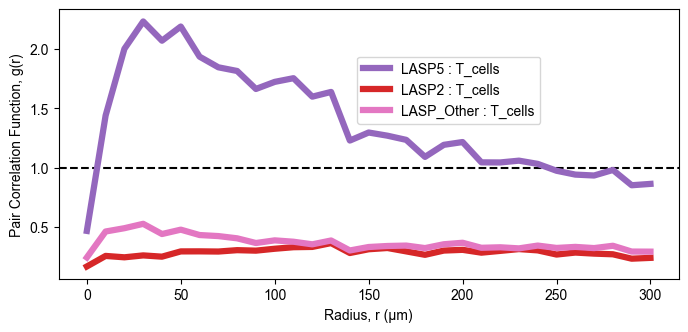

In [41]:
fig = plotDistanceCor(domain,300)
fig.savefig(folder+'/figures/AD264H1/Distribution_LASP_T cells_colocolization.pdf')

### BR

                       in_tissue  array_row  array_col  n_counts Tacco_final  \
s_008um_00269_00526-1          1        269        526      18.0   Adipocyte   
s_008um_00547_00611-1          1        547        611     151.0   Adipocyte   
s_008um_00260_00253-1          1        260        253     866.0         LHS   
s_008um_00129_00000-1          1        129          0      23.0   Adipocyte   
s_008um_00433_00599-1          1        433        599      33.0   Adipocyte   

                          tacco2 region     lasp_ct            X            Y  
s_008um_00269_00526-1  Adipocyte    NaN  Background  6786.506913  2192.716637  
s_008um_00547_00611-1  Adipocyte    NaN  Background  7158.175926  3454.947121  
s_008um_00260_00253-1        LHS    NaN  Background  5551.287896  2139.158678  
s_008um_00129_00000-1  Adipocyte    NaN  Background  4412.323214  1534.366015  
s_008um_00433_00599-1  Adipocyte    NaN  Background  7109.214948  2938.413869  


(<Figure size 640x480 with 2 Axes>, <Axes: >)

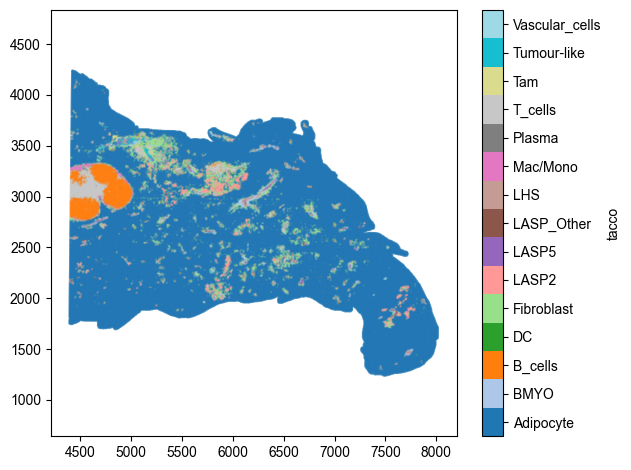

In [19]:
aa = pd.read_csv(folder+'results/BR/data4muspan_BR.csv',index_col=0)
#microns_per_pixel = 0.1329321241441775
#coords = aa[['X','Y']].values
#coords_um = coords * microns_per_pixel
#aa[['X','Y']] = coords_um
print(aa.head())

y_min, y_max = aa['Y'].min(), aa['Y'].max()
aa['Y'] = y_max + y_min - aa['Y']

aa['tacco_ct'] = aa['Tacco_final']
aa['tacco_ct'][aa['tacco_ct'] == 'LASP_Other'] = 'LASP_other'
points = np.asarray([aa['X'], aa['Y']])
domain = ms.domain('AA')
domain.add_points(points.T, 'Cell centres')
domain.add_labels('tacco', aa['tacco2'])
ms.visualise.visualise(domain, 'tacco', ax=plt.gca(),marker_size=0.01)

Text(0.5, 1.0, 'Co-existence of LASP2 and T cells')

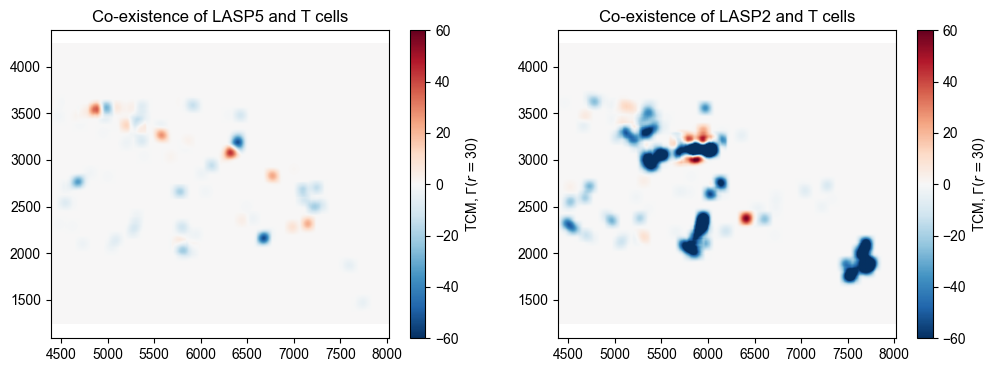

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ms.spatial_statistics.topographical_correlation_map(domain, 
                                                    ('tacco', 'LASP5'),
                                                    ('tacco', 'T_cells'), 
                                                    radius_of_interest=30,
                                                    visualise_output=True,
                                                    kernel_radius=80,
                                                    kernel_sigma=50,
                                                    #mesh_step=20,
                                                    max_correlation_threshold=30,
                                                    #include_boundaries=('Collection', 'boundary'),
                                                    visualise_tcm_kwargs={'ax': axes[0],'colorbar_limit':60})
axes[0].set_title('Co-existence of LASP5 and T cells')

ms.spatial_statistics.topographical_correlation_map(domain, 
                                                    ('tacco', 'LASP2'),
                                                    ('tacco', 'T_cells'), 
                                                    radius_of_interest=30,
                                                    visualise_output=True, 
                                                    kernel_radius=80,
                                                    kernel_sigma=50,
                                                    #mesh_step=20,
                                                    max_correlation_threshold=30,
                                                    #include_boundaries=('Collection', 'boundary'),
                                                    visualise_tcm_kwargs={'ax': axes[1],'colorbar_limit':60})
axes[1].set_title('Co-existence of LASP2 and T cells')

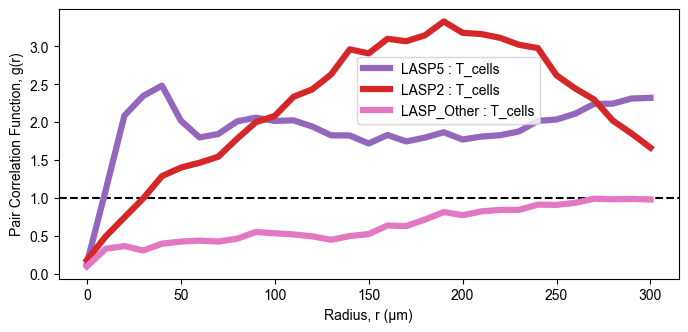

In [31]:
fig = plotDistanceCor(domain,300,10)